# 05 — Outlier Analysis

The regression model in notebook 04 explained about 35–40% of variance in youth justice referral rates. That means 60–65% is unexplained. The LAs that the model gets most wrong are the most interesting ones — they are either doing something right that protects children despite high exclusion rates, or something is going wrong that deprivation alone doesn't account for.

This notebook investigates:

1. **Quadrant analysis** — LAs split by whether exclusion rates and FTE rates are above/below median
2. **Residual analysis** — which LAs does the deprivation model most over- and under-predict?
3. **The London puzzle** — a cluster of London boroughs with low exclusion rates but very high FTE rates
4. **Case studies** — Nottingham, Isle of Wight, Blackburn with Darwen, and North Tyneside
5. **What the outliers suggest** about where to look next

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from pathlib import Path

PROCESSED = Path('../data/processed')
OUTPUTS   = Path('../outputs')

plt.style.use('dark_background')
ACCENT  = '#e05c5c'
ACCENT2 = '#5c9ee0'
AMBER   = '#e0a05c'
GREEN   = '#5ce08a'
NEUTRAL = '#888888'

df   = pd.read_csv(PROCESSED / 'analytical_table.csv')
core = df[df['usable_for_core_analysis'] == True].copy()

la_avg = core.groupby(['new_la_code', 'la_name']).agg(
    susp_no_sen = ('susp_rate_no_identified_sen',    'mean'),
    excl_no_sen = ('perm_excl_rate_no_identified_sen','mean'),
    excl_sen    = ('perm_excl_rate_sen_support',     'mean'),
    excl_ehc    = ('perm_excl_rate_ehc_plan',        'mean'),
    fte         = ('fte_rate_per_100k',              'mean'),
    imd         = ('imd_avg_score',                  'first'),
    pct_semh    = ('pct_semh',                       'first'),
    pct_spld    = ('pct_spld',                       'first'),
    pct_asd     = ('pct_asd',                        'first'),
).reset_index().dropna()

# Deprivation-only model residuals
X = np.column_stack([np.ones(len(la_avg)), la_avg['imd'].values])
y = la_avg['fte'].values
beta = np.linalg.lstsq(X, y, rcond=None)[0]
la_avg['fte_predicted'] = X @ beta
la_avg['residual']      = la_avg['fte'] - la_avg['fte_predicted']
la_avg['residual_std']  = (la_avg['residual'] - la_avg['residual'].mean()) / la_avg['residual'].std()

# Quadrant classification
excl_med = la_avg['excl_sen'].median()
fte_med  = la_avg['fte'].median()

la_avg['quadrant'] = np.where(
    (la_avg['excl_sen'] >= excl_med) & (la_avg['fte'] >= fte_med), 'High excl / High FTE',
    np.where(
        (la_avg['excl_sen'] >= excl_med) & (la_avg['fte'] <  fte_med), 'High excl / Low FTE',
        np.where(
            (la_avg['excl_sen'] <  excl_med) & (la_avg['fte'] >= fte_med), 'Low excl / High FTE',
            'Low excl / Low FTE'
        )
    )
)

print(f'LA dataset: {len(la_avg)} local authorities')
print('Quadrant counts:')
print(la_avg['quadrant'].value_counts().to_string())

LA dataset: 116 local authorities
Quadrant counts:
quadrant
High excl / Low FTE     30
Low excl / High FTE     30
High excl / High FTE    28
Low excl / Low FTE      28


## 1. Quadrant Map

Splitting LAs by median exclusion rate and median FTE rate gives four groups. The two interesting quadrants are the ones that cut against the expected pattern: **High excl / Low FTE** (protective factors at work?) and **Low excl / High FTE** (other pathways to the justice system?).

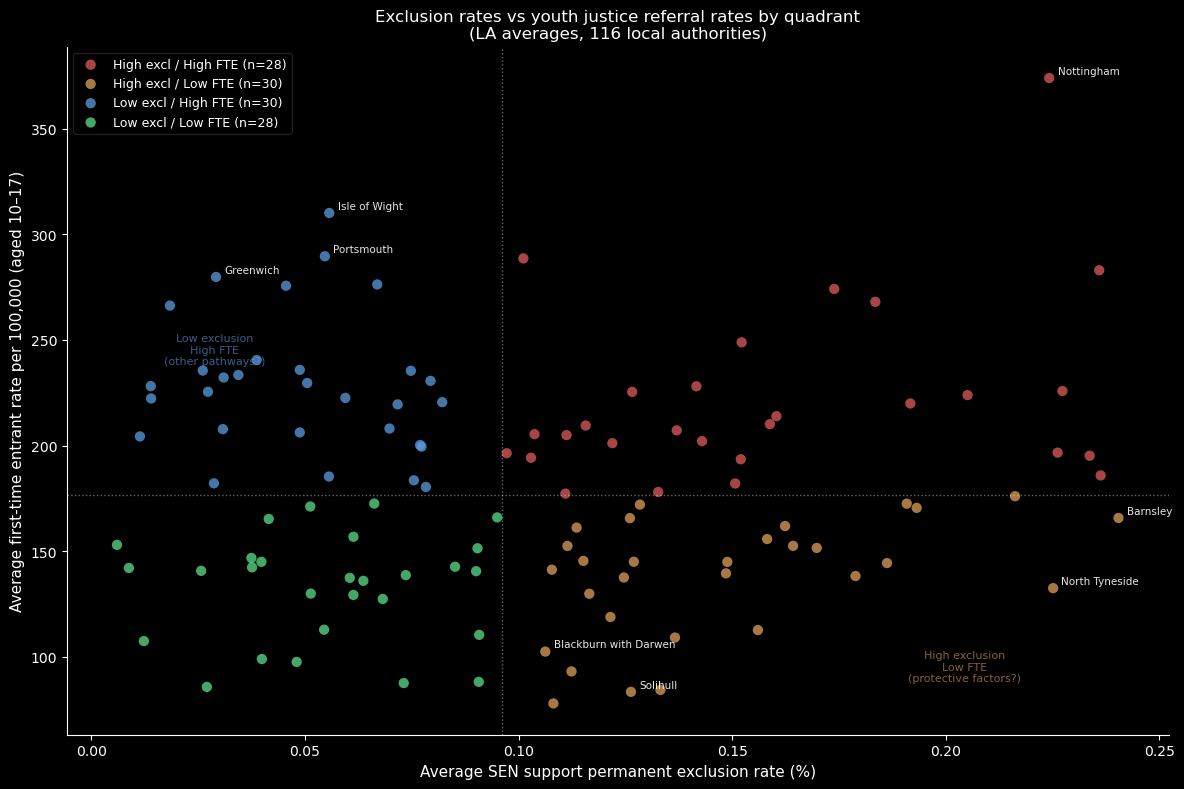

In [2]:
quadrant_colours = {
    'High excl / High FTE': ACCENT,
    'High excl / Low FTE':  AMBER,
    'Low excl / High FTE':  ACCENT2,
    'Low excl / Low FTE':   GREEN,
}

fig, ax = plt.subplots(figsize=(12, 8))

for quadrant, group in la_avg.groupby('quadrant'):
    ax.scatter(group['excl_sen'], group['fte'],
               color=quadrant_colours[quadrant], label=f'{quadrant} (n={len(group)})',
               alpha=0.75, s=55, edgecolors='none')

ax.axvline(excl_med, color='white', linestyle=':', linewidth=1, alpha=0.4)
ax.axhline(fte_med,  color='white', linestyle=':', linewidth=1, alpha=0.4)

# Annotate notable outliers
annotate = [
    'Nottingham', 'Isle of Wight', 'Blackburn with Darwen',
    'North Tyneside', 'Barnsley', 'Solihull', 'Greenwich', 'Portsmouth'
]
for _, row in la_avg[la_avg['la_name'].isin(annotate)].iterrows():
    ax.annotate(row['la_name'], (row['excl_sen'], row['fte']),
                textcoords='offset points', xytext=(6, 3), fontsize=7.5, alpha=0.9)

# Quadrant labels
ax.text(excl_med * 0.3, fte_med * 1.35, 'Low exclusion\nHigh FTE\n(other pathways?)',
        color=ACCENT2, fontsize=8, alpha=0.6, ha='center')
ax.text(la_avg['excl_sen'].max() * 0.85, fte_med * 0.5, 'High exclusion\nLow FTE\n(protective factors?)',
        color=AMBER, fontsize=8, alpha=0.6, ha='center')

ax.set_xlabel('Average SEN support permanent exclusion rate (%)', fontsize=11)
ax.set_ylabel('Average first-time entrant rate per 100,000 (aged 10–17)', fontsize=11)
ax.set_title('Exclusion rates vs youth justice referral rates by quadrant\n'
             '(LA averages, 116 local authorities)', fontsize=12)
ax.legend(fontsize=9, framealpha=0.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUTS / 'quadrant_map.png', dpi=150, bbox_inches='tight')
plt.show()

In [3]:
# Profile comparison across quadrants
profile = la_avg.groupby('quadrant')[['imd', 'excl_sen', 'fte', 'pct_semh', 'pct_spld', 'pct_asd']].mean().round(2)
print('Mean profile by quadrant:')
print(profile.to_string())
print()
print('Key observations:')
print(f'  High excl / Low FTE LAs have lower deprivation (IMD={profile.loc["High excl / Low FTE","imd"]:.1f})')
print(f'  than High excl / High FTE LAs (IMD={profile.loc["High excl / High FTE","imd"]:.1f})')
print(f'  Low excl / High FTE LAs are more deprived than their FTE rate suggests they should be')
print(f'  High excl / Low FTE LAs have notably higher SPLD% ({profile.loc["High excl / Low FTE","pct_spld"]:.1f}%)')
print(f'  vs Low excl / High FTE ({profile.loc["Low excl / High FTE","pct_spld"]:.1f}%)')

Mean profile by quadrant:
                        imd  excl_sen     fte  pct_semh  pct_spld  pct_asd
quadrant                                                                  
High excl / High FTE  31.97      0.16  221.89     21.45      8.93    14.14
High excl / Low FTE   22.98      0.15  137.93     21.39     11.15    14.14
Low excl / High FTE   26.19      0.05  228.88     18.00      8.07    16.89
Low excl / Low FTE    17.53      0.06  132.97     18.46     10.43    15.51

Key observations:
  High excl / Low FTE LAs have lower deprivation (IMD=23.0)
  than High excl / High FTE LAs (IMD=32.0)
  Low excl / High FTE LAs are more deprived than their FTE rate suggests they should be
  High excl / Low FTE LAs have notably higher SPLD% (11.2%)
  vs Low excl / High FTE (8.1%)


## 2. Residual Analysis

The quadrant approach uses raw values. The residual approach asks a sharper question: which LAs have *more* or *fewer* youth justice referrals than their level of deprivation would predict? These are the genuine outliers.

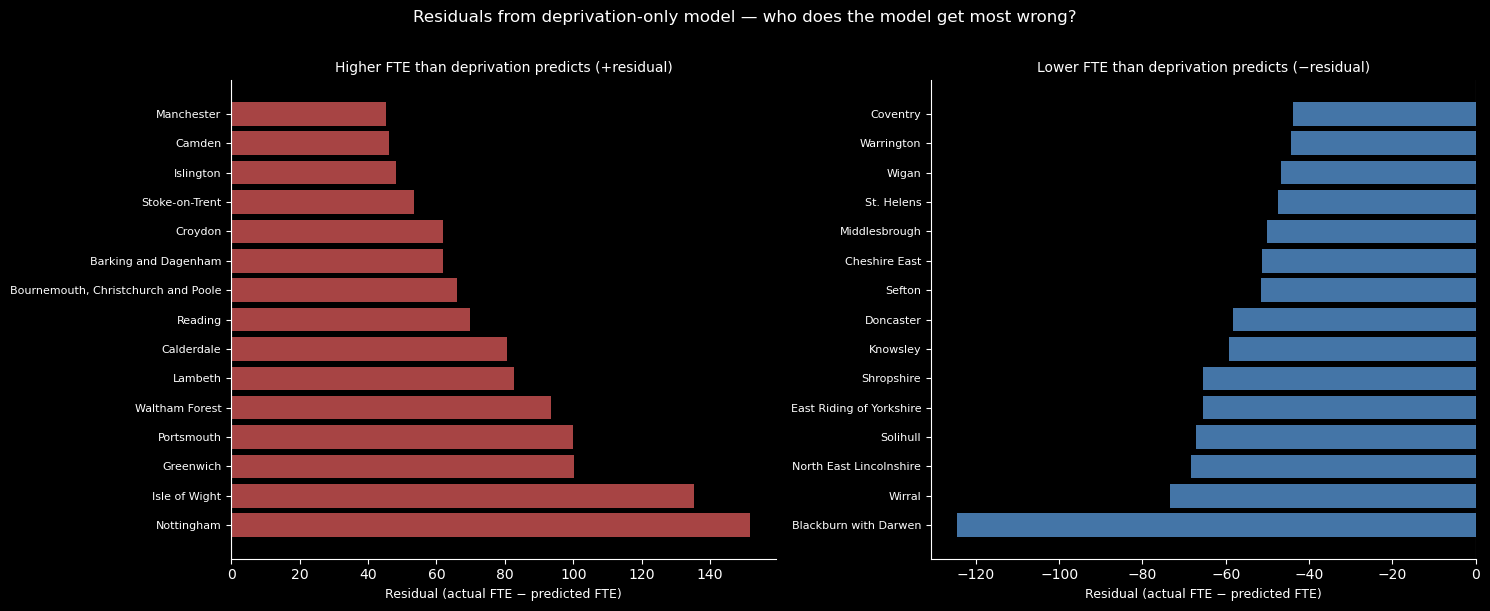

In [4]:
# Top and bottom residuals
top_resid    = la_avg.nlargest(15, 'residual')
bottom_resid = la_avg.nsmallest(15, 'residual')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, data, title, colour in [
    (axes[0], top_resid,    'Higher FTE than deprivation predicts (+residual)', ACCENT),
    (axes[1], bottom_resid, 'Lower FTE than deprivation predicts (−residual)',  ACCENT2),
]:
    data_sorted = data.sort_values('residual', ascending=(colour == ACCENT2))
    bars = ax.barh(range(len(data_sorted)), data_sorted['residual'],
                   color=colour, alpha=0.75, edgecolor='none')
    ax.set_yticks(range(len(data_sorted)))
    ax.set_yticklabels(data_sorted['la_name'], fontsize=8)
    ax.set_xlabel('Residual (actual FTE − predicted FTE)', fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.axvline(0, color='white', linewidth=0.8, alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Residuals from deprivation-only model — who does the model get most wrong?',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS / 'residuals.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
print('Top 12 positive residuals (much higher FTE than deprivation predicts):')
cols = ['la_name', 'fte', 'fte_predicted', 'residual', 'imd', 'excl_sen', 'pct_semh']
print(la_avg.nlargest(12, 'residual')[cols].round(2).to_string(index=False))
print()
print('Top 12 negative residuals (much lower FTE than deprivation predicts):')
print(la_avg.nsmallest(12, 'residual')[cols].round(2).to_string(index=False))

Top 12 positive residuals (much higher FTE than deprivation predicts):
                            la_name    fte  fte_predicted  residual   imd  excl_sen  pct_semh
                         Nottingham 373.99         222.39    151.60 34.89      0.22     24.30
                      Isle of Wight 310.10         174.91    135.18 23.29      0.06     21.87
                          Greenwich 279.80         179.70    100.09 24.46      0.03     15.58
                         Portsmouth 289.61         189.67     99.94 26.90      0.05     24.86
                     Waltham Forest 276.27         182.75     93.51 25.21      0.07     15.85
                            Lambeth 266.24         183.63     82.62 25.42      0.02     16.85
                         Calderdale 268.03         187.43     80.60 26.35      0.18     17.97
                            Reading 229.61         159.87     69.74 19.62      0.05     18.15
Bournemouth, Christchurch and Poole 219.93         153.95     65.98 18.17      0.19

## 3. The London Puzzle

The Low excl / High FTE quadrant is dominated by London boroughs. These are LAs that exclude relatively few SEN children but have very high youth justice referral rates. If exclusion were driving the pathway, we'd expect the opposite.

This is worth examining carefully. Several hypotheses:

- London boroughs may have better SEN identification and support, meaning fewer children reach the exclusion threshold — but the underlying social conditions still produce justice system contact via other routes (gangs, county lines, knife crime)
- London boroughs have large, transient populations making LA-level data noisier
- The gang and county lines pipeline is a distinct pathway from the exclusion pathway, and it is particularly active in inner London

In [6]:
# Flag London boroughs
london_boroughs = [
    'Barking and Dagenham', 'Barnet', 'Bexley', 'Brent', 'Bromley',
    'Camden', 'Croydon', 'Ealing', 'Enfield', 'Greenwich', 'Hackney',
    'Hammersmith and Fulham', 'Haringey', 'Harrow', 'Havering', 'Hillingdon',
    'Hounslow', 'Islington', 'Kensington and Chelsea', 'Kingston upon Thames',
    'Lambeth', 'Lewisham', 'Merton', 'Newham', 'Redbridge',
    'Richmond upon Thames', 'Southwark', 'Sutton', 'Tower Hamlets',
    'Waltham Forest', 'Wandsworth', 'Westminster', 'City of London'
]

la_avg['is_london'] = la_avg['la_name'].isin(london_boroughs)

london = la_avg[la_avg['is_london']]
rest   = la_avg[~la_avg['is_london']]

print('London vs rest of England comparison:')
print(f'{"":30s} {"London":>12} {"Rest of England":>16}')
for col, label in [
    ('excl_sen',  'SEN support excl rate'),
    ('fte',       'FTE rate per 100k'),
    ('imd',       'IMD avg score'),
    ('pct_semh',  'SEMH %'),
    ('pct_spld',  'SPLD %'),
]:
    print(f'{label:30s} {london[col].median():>12.2f} {rest[col].median():>16.2f}')

London vs rest of England comparison:
                                     London  Rest of England
SEN support excl rate                  0.04             0.12
FTE rate per 100k                    183.73           172.50
IMD avg score                         21.90            26.49
SEMH %                                16.44            20.95
SPLD %                                 8.11             9.38


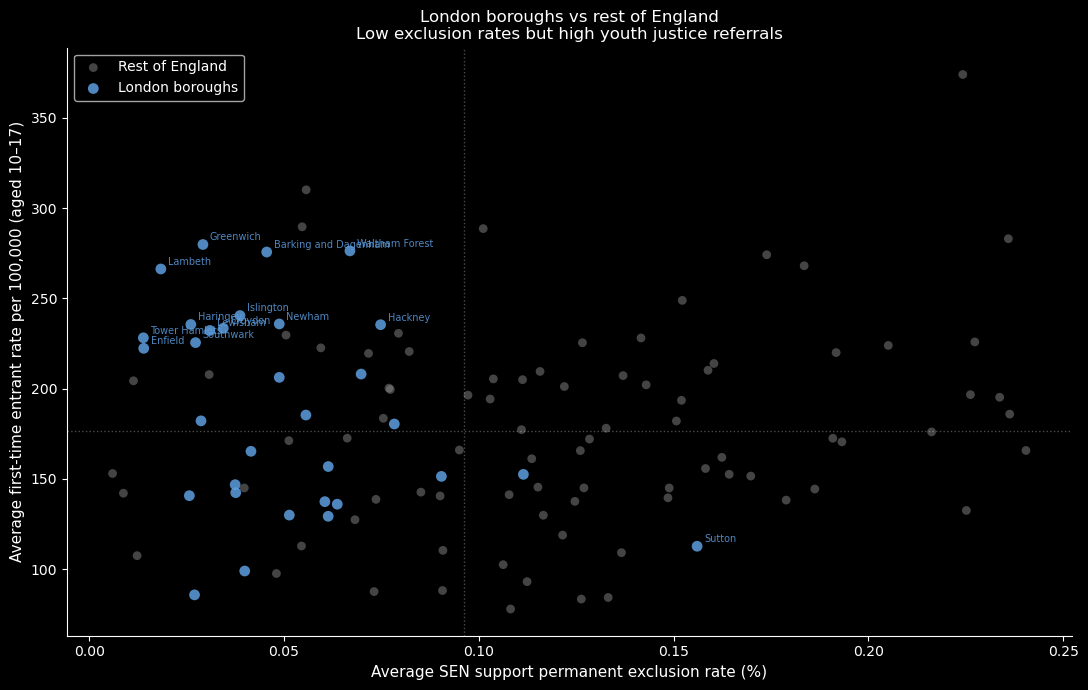

London boroughs have substantially lower SEN exclusion rates than the rest of England
but substantially higher youth justice referral rates.
This pattern is consistent with London having a distinct pathway to the youth
justice system — one that operates largely independently of school exclusion.


In [7]:
fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(rest['excl_sen'], rest['fte'],
           color=NEUTRAL, alpha=0.5, s=40, edgecolors='none', label='Rest of England')
ax.scatter(london['excl_sen'], london['fte'],
           color=ACCENT2, alpha=0.85, s=60, edgecolors='none', label='London boroughs')

# Annotate London boroughs
for _, row in london.iterrows():
    if row['fte'] > 220 or row['excl_sen'] > 0.12:
        ax.annotate(row['la_name'], (row['excl_sen'], row['fte']),
                    textcoords='offset points', xytext=(5, 3), fontsize=7, color=ACCENT2, alpha=0.85)

ax.axvline(excl_med, color='white', linestyle=':', linewidth=1, alpha=0.3)
ax.axhline(fte_med,  color='white', linestyle=':', linewidth=1, alpha=0.3)

ax.set_xlabel('Average SEN support permanent exclusion rate (%)', fontsize=11)
ax.set_ylabel('Average first-time entrant rate per 100,000 (aged 10–17)', fontsize=11)
ax.set_title('London boroughs vs rest of England\nLow exclusion rates but high youth justice referrals', fontsize=12)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUTS / 'london_vs_rest.png', dpi=150, bbox_inches='tight')
plt.show()

print('London boroughs have substantially lower SEN exclusion rates than the rest of England')
print('but substantially higher youth justice referral rates.')
print('This pattern is consistent with London having a distinct pathway to the youth')
print('justice system — one that operates largely independently of school exclusion.')

## 4. Case Studies

Four LAs worth examining individually — two that the model massively underpredicts, two that it massively overpredicts.

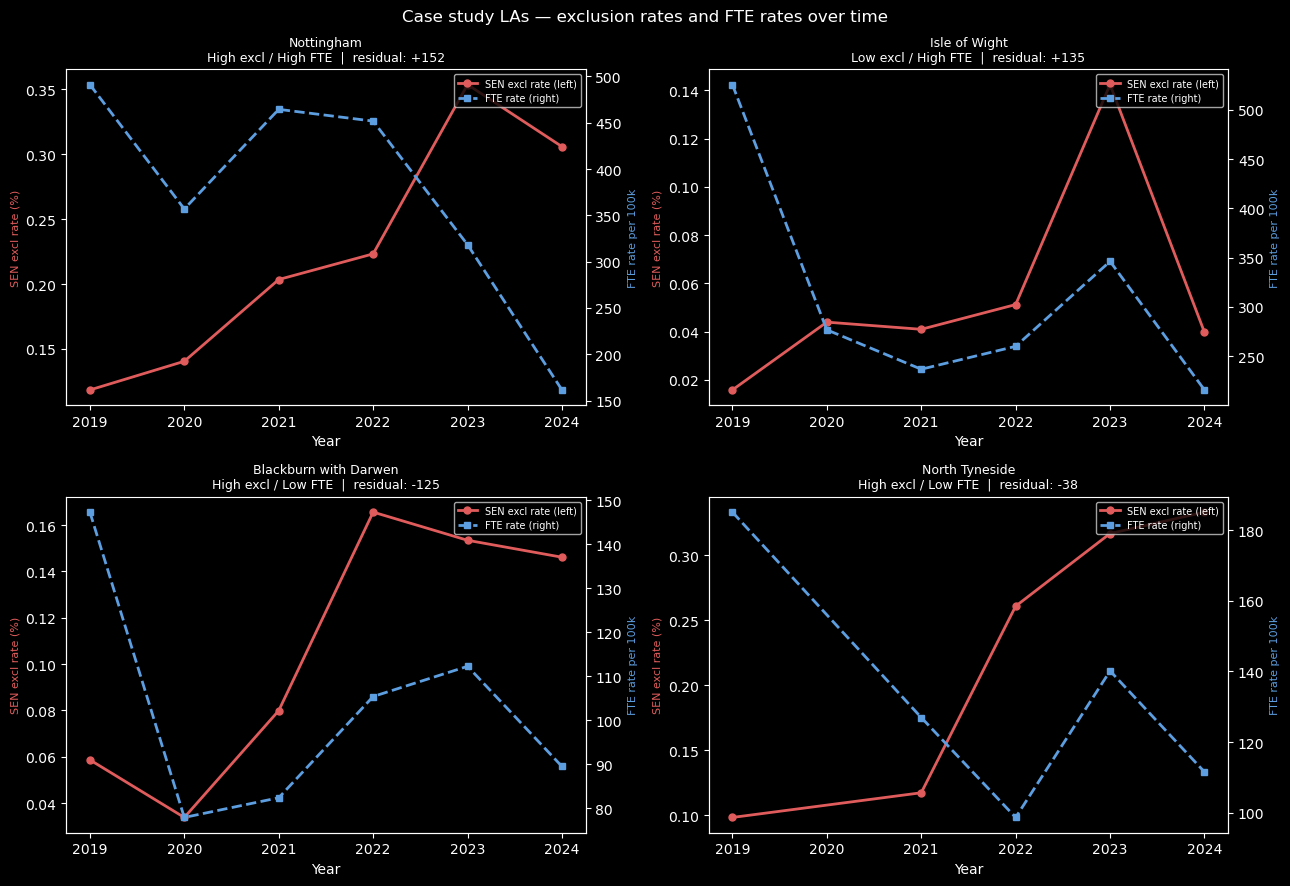

In [8]:
# Pull time series for case study LAs
case_study_las = ['Nottingham', 'Isle of Wight', 'Blackburn with Darwen', 'North Tyneside']

case_data = core[core['la_name'].isin(case_study_las)].copy()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Case study LAs — exclusion rates and FTE rates over time', fontsize=12)

for ax, la_name in zip(axes.flat, case_study_las):
    la_data = case_data[case_data['la_name'] == la_name].sort_values('dfe_start_year')
    la_summary = la_avg[la_avg['la_name'] == la_name].iloc[0]

    ax2 = ax.twinx()

    ax.plot(la_data['dfe_start_year'], la_data['perm_excl_rate_sen_support'],
            color=ACCENT, marker='o', linewidth=2, markersize=5, label='SEN excl rate (left)')
    ax2.plot(la_data['dfe_start_year'], la_data['fte_rate_per_100k'],
             color=ACCENT2, marker='s', linewidth=2, markersize=5, linestyle='--', label='FTE rate (right)')

    resid = la_summary['residual']
    resid_str = f'+{resid:.0f}' if resid > 0 else f'{resid:.0f}'
    quadrant  = la_summary['quadrant']
    ax.set_title(f'{la_name}\n{quadrant}  |  residual: {resid_str}', fontsize=9)
    ax.set_xlabel('Year')
    ax.set_ylabel('SEN excl rate (%)', color=ACCENT, fontsize=8)
    ax2.set_ylabel('FTE rate per 100k', color=ACCENT2, fontsize=8)
    ax.spines['top'].set_visible(False)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc='upper right')

plt.tight_layout()
plt.savefig(OUTPUTS / 'case_studies.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Detailed profiles for each case study LA
print('Case study LA profiles:')
print(f'{"":30s} {"Nottingham":>14} {"Isle of Wight":>14} {"Blackburn w D":>14} {"N Tyneside":>12}')
print('-' * 86)

las_order = ['Nottingham', 'Isle of Wight', 'Blackburn with Darwen', 'North Tyneside']
case_profiles = la_avg[la_avg['la_name'].isin(las_order)].set_index('la_name')

for col, label in [
    ('imd',          'IMD score'),
    ('excl_sen',     'SEN support excl rate'),
    ('excl_no_sen',  'No-SEN excl rate'),
    ('susp_no_sen',  'No-SEN suspension rate'),
    ('fte',          'FTE rate per 100k'),
    ('fte_predicted','Predicted FTE (deprivation)'),
    ('residual',     'Residual'),
    ('pct_semh',     'SEMH %'),
    ('pct_spld',     'SPLD %'),
    ('pct_asd',      'ASD %'),
]:
    vals = [f'{case_profiles.loc[la, col]:.2f}' if la in case_profiles.index else 'N/A'
            for la in las_order]
    print(f'{label:30s} {vals[0]:>14} {vals[1]:>14} {vals[2]:>14} {vals[3]:>12}')

Case study LA profiles:
                                   Nottingham  Isle of Wight  Blackburn w D   N Tyneside
--------------------------------------------------------------------------------------
IMD score                               34.89          23.29          36.01        22.28
SEN support excl rate                    0.22           0.06           0.11         0.23
No-SEN excl rate                         0.04           0.02           0.02         0.05
No-SEN suspension rate                   3.31           2.11           1.42         1.99
FTE rate per 100k                      373.99         310.10         102.46       132.49
Predicted FTE (deprivation)            222.39         174.91         226.99       170.76
Residual                               151.60         135.18        -124.53       -38.27
SEMH %                                  24.30          21.87          22.55        23.92
SPLD %                                   6.89          11.16           7.32        13.21

In [10]:
# Commentary on each case
print('=== Case study notes ===')
print()
print('NOTTINGHAM (residual +152 — extreme outlier)')
print('  FTE rate of 374 per 100k against a predicted 222. High deprivation (34.9),')
print('  high SEN exclusion rate (0.22), and high SEMH% (24.3). Everything points')
print('  in the same direction. The residual may reflect specific local conditions —')
print('  county lines activity, gang territory, or resourcing gaps — that are not')
print('  captured by any of our variables.')
print()
print('ISLE OF WIGHT (residual +135 — surprising)')
print('  FTE rate of 310 per 100k against a predicted 175. IMD of only 23.3 —')
print('  relatively low deprivation. Yet one of the highest FTE rates in England.')
print('  Low SEN exclusion rate (0.056). The island geography may create isolation')
print('  effects: limited alternative provision after exclusion, limited employment,')
print('  limited pathways out of the justice system once entered.')
print()
print('BLACKBURN WITH DARWEN (residual -125 — protective outlier)')
print('  FTE rate of only 102 per 100k against a predicted 227. High deprivation')
print('  (36.0). This is an LA that, by the model, should look like Nottingham but')
print('  actually looks very different. Worth investigating: what is Blackburn doing')
print('  that reduces youth justice contact despite high deprivation? Community')
print('  programmes, restorative justice approaches, diversion schemes?')
print()
print('NORTH TYNESIDE (residual -38 — High excl / Low FTE)')
print('  High SEN exclusion rate (0.225) but below-median FTE rate (132).')
print('  Relatively low deprivation for the North East (22.3). The dissociation')
print('  between exclusion rate and justice outcomes here is notable — if exclusion')
print('  were directly driving the pathway, we would expect the opposite.')

=== Case study notes ===

NOTTINGHAM (residual +152 — extreme outlier)
  FTE rate of 374 per 100k against a predicted 222. High deprivation (34.9),
  high SEN exclusion rate (0.22), and high SEMH% (24.3). Everything points
  in the same direction. The residual may reflect specific local conditions —
  county lines activity, gang territory, or resourcing gaps — that are not
  captured by any of our variables.

ISLE OF WIGHT (residual +135 — surprising)
  FTE rate of 310 per 100k against a predicted 175. IMD of only 23.3 —
  relatively low deprivation. Yet one of the highest FTE rates in England.
  Low SEN exclusion rate (0.056). The island geography may create isolation
  effects: limited alternative provision after exclusion, limited employment,
  limited pathways out of the justice system once entered.

BLACKBURN WITH DARWEN (residual -125 — protective outlier)
  FTE rate of only 102 per 100k against a predicted 227. High deprivation
  (36.0). This is an LA that, by the model, should 

## 5. What the High excl / Low FTE LAs Have in Common

These are the LAs that exclude the most SEN children but have below-median youth justice referral rates. If a protective factor exists, it should show up here.

In [11]:
high_low = la_avg[la_avg['quadrant'] == 'High excl / Low FTE'].copy()
low_high = la_avg[la_avg['quadrant'] == 'Low excl / High FTE'].copy()
high_high = la_avg[la_avg['quadrant'] == 'High excl / High FTE'].copy()

print('High excl / Low FTE LAs (sorted by exclusion rate):')
print(high_low.sort_values('excl_sen', ascending=False)[
    ['la_name', 'excl_sen', 'fte', 'imd', 'pct_semh', 'pct_spld', 'residual']
].round(2).to_string(index=False))

High excl / Low FTE LAs (sorted by exclusion rate):
                  la_name  excl_sen    fte   imd  pct_semh  pct_spld  residual
                 Barnsley      0.24 165.72 29.93     19.64     18.70    -36.37
           North Tyneside      0.23 132.49 22.28     23.92     13.21    -38.27
               Sunderland      0.22 175.99 30.59     20.52      4.48    -28.78
            Wolverhampton      0.19 170.50 32.10     21.07     11.76    -40.48
                   Bolton      0.19 172.48 30.69     17.16      8.90    -32.72
                 Cornwall      0.19 144.36 23.07     22.03     12.11    -29.65
                    Wigan      0.18 138.21 25.71     23.93      6.78    -46.60
                Gateshead      0.17 151.53 28.22     21.80      7.56    -43.54
                Stockport      0.16 152.51 20.83     23.67      8.36    -12.29
         Stockton-on-Tees      0.16 161.90 25.79     16.27      7.27    -23.23
           Northumberland      0.16 155.72 22.08     28.35      7.23    -14.22


In [12]:
# Statistical comparison: High excl/Low FTE vs High excl/High FTE
# What's different between the two high-exclusion groups?
print('Comparing High excl / Low FTE vs High excl / High FTE:')
print(f'{"":25s} {"High/Low":>12} {"High/High":>12} {"p-value":>10}')
print('-' * 62)

for col, label in [
    ('imd',     'IMD score'),
    ('fte',     'FTE rate'),
    ('pct_semh','SEMH %'),
    ('pct_spld','SPLD %'),
    ('pct_asd', 'ASD %'),
]:
    a = high_low[col].dropna()
    b = high_high[col].dropna()
    t, p = stats.ttest_ind(a, b)
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
    print(f'{label:25s} {a.mean():>12.2f} {b.mean():>12.2f} {p:>10.4f} {sig}')

print()
print('The high excl/low FTE group has significantly lower deprivation (IMD).')
print('This suggests deprivation — not exclusion rate — is driving the difference.')
print('High-exclusion LAs with low FTE rates are simply less deprived than')
print('high-exclusion LAs with high FTE rates.')

Comparing High excl / Low FTE vs High excl / High FTE:
                              High/Low    High/High    p-value
--------------------------------------------------------------
IMD score                        22.98        31.97     0.0000 ***
FTE rate                        137.93       221.89     0.0000 ***
SEMH %                           21.39        21.45     0.9433 
SPLD %                           11.15         8.93     0.0192 *
ASD %                            14.14        14.14     0.9986 

The high excl/low FTE group has significantly lower deprivation (IMD).
This suggests deprivation — not exclusion rate — is driving the difference.
High-exclusion LAs with low FTE rates are simply less deprived than
high-exclusion LAs with high FTE rates.


## Summary: What the Outlier Analysis Tells Us

### The dominant story is deprivation, not exclusion

When we split LAs into quadrants or rank them by model residuals, the clearest pattern is that **the high FTE outliers are mostly explained by high deprivation that the simple IMD score doesn't fully capture**. Nottingham, inner London boroughs, Portsmouth — these are all places with concentrated disadvantage, gang activity, county lines presence, and limited opportunities for young people.

### London is a distinct case

London boroughs cluster strongly in the Low excl / High FTE quadrant. They have lower SEN exclusion rates than comparable deprived areas outside London — possibly because they have better-resourced SEN identification and support — but very high youth justice referral rates. This suggests **a parallel pathway** operating in London that is largely independent of school exclusion: gang recruitment, county lines, and the specific social ecology of inner-city London.

### The protective outliers are hard to explain from this data alone

Blackburn with Darwen stands out. High deprivation, moderate exclusion rates, but a youth justice referral rate less than half of what the model predicts. Something is working there. Whether it's specific diversion programmes, community structures, restorative justice approaches, or something else is not answerable from this dataset.

### What this means for the original hypothesis

The outlier analysis reinforces the conclusion from notebook 04: **the school-to-prison pipeline, if it operates as hypothesised, is not visible at LA aggregate level because it is overwhelmed by the deprivation signal**. The children in the pipeline are a minority of all excluded children and a small fraction of the youth population of any LA — their signal disappears in the aggregate.

The research that would actually answer the question remains the same: linked individual-level data across school exclusion records, CAMHS referrals, and youth justice system entry. That data exists in government systems. It has not been linked and made available for research. That is the gap this project identifies.

---

